# 02 Feature Selection: Correlation & VIF

1. Drop US-only columns and target leakage columns
2. Handle missing values
3. Remove high-correlation pairs (|r| > 0.85)
4. VIF screening (VIF > 10)

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import (
    load_data, set_seed, compute_vif, remove_high_corr_features,
    prepare_features, label_potential
)

set_seed(42)

## Load & Prepare

In [2]:
df = load_data('../deepsolar_tract.csv')
target_col = 'tile_count'

# Drop US-only columns and target leakage columns, but KEEP tile_count
from src.features import get_target_cols
target_leakage = [c for c in get_target_cols() if c != target_col]

df_features = prepare_features(df, drop_us_only=True, drop_targets=False, drop_ids=True)
df_features = df_features.drop(columns=[c for c in target_leakage if c in df_features.columns])
print('Feature columns after dropping US-only/targets:', df_features.shape[1])

Feature columns after dropping US-only/targets: 121


## Missing Value Imputation

In [3]:
# Identify numeric columns
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]  # exclude target to avoid duplicates
print(f'Numeric columns: {len(numeric_cols)}')

# Drop rows with missing target
df_clean = df_features[numeric_cols + [target_col]].dropna(subset=[target_col]).copy()

# Impute remaining missing values with median
for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f'Rows after dropping missing target: {len(df_clean)}')
print(f'Any remaining missing: {df_clean.isnull().sum().sum()}')

Numeric columns: 119
Rows after dropping missing target: 72537
Any remaining missing: 0


## Define Target (Tertile Classification)

In [4]:
q33 = df_clean[target_col].quantile(0.33)
q66 = df_clean[target_col].quantile(0.66)
print(f'Quantiles: 33%={q33:.2f}, 66%={q66:.2f}')

df_clean['potential_label'] = label_potential(df_clean[target_col], q33, q66)
print(df_clean['potential_label'].value_counts().sort_index())

Quantiles: 33%=1.00, 66%=11.00
potential_label
0    24279
1    24174
2    24084
Name: count, dtype: int64


## Step 1: Correlation Screening

In [5]:
feature_cols = [c for c in numeric_cols if c != target_col]
corr_selected = remove_high_corr_features(df_clean, feature_cols, target_col, threshold=0.85)
print(f'Features after correlation screening: {len(corr_selected)} (dropped {len(feature_cols) - len(corr_selected)})')

Features after correlation screening: 94 (dropped 25)


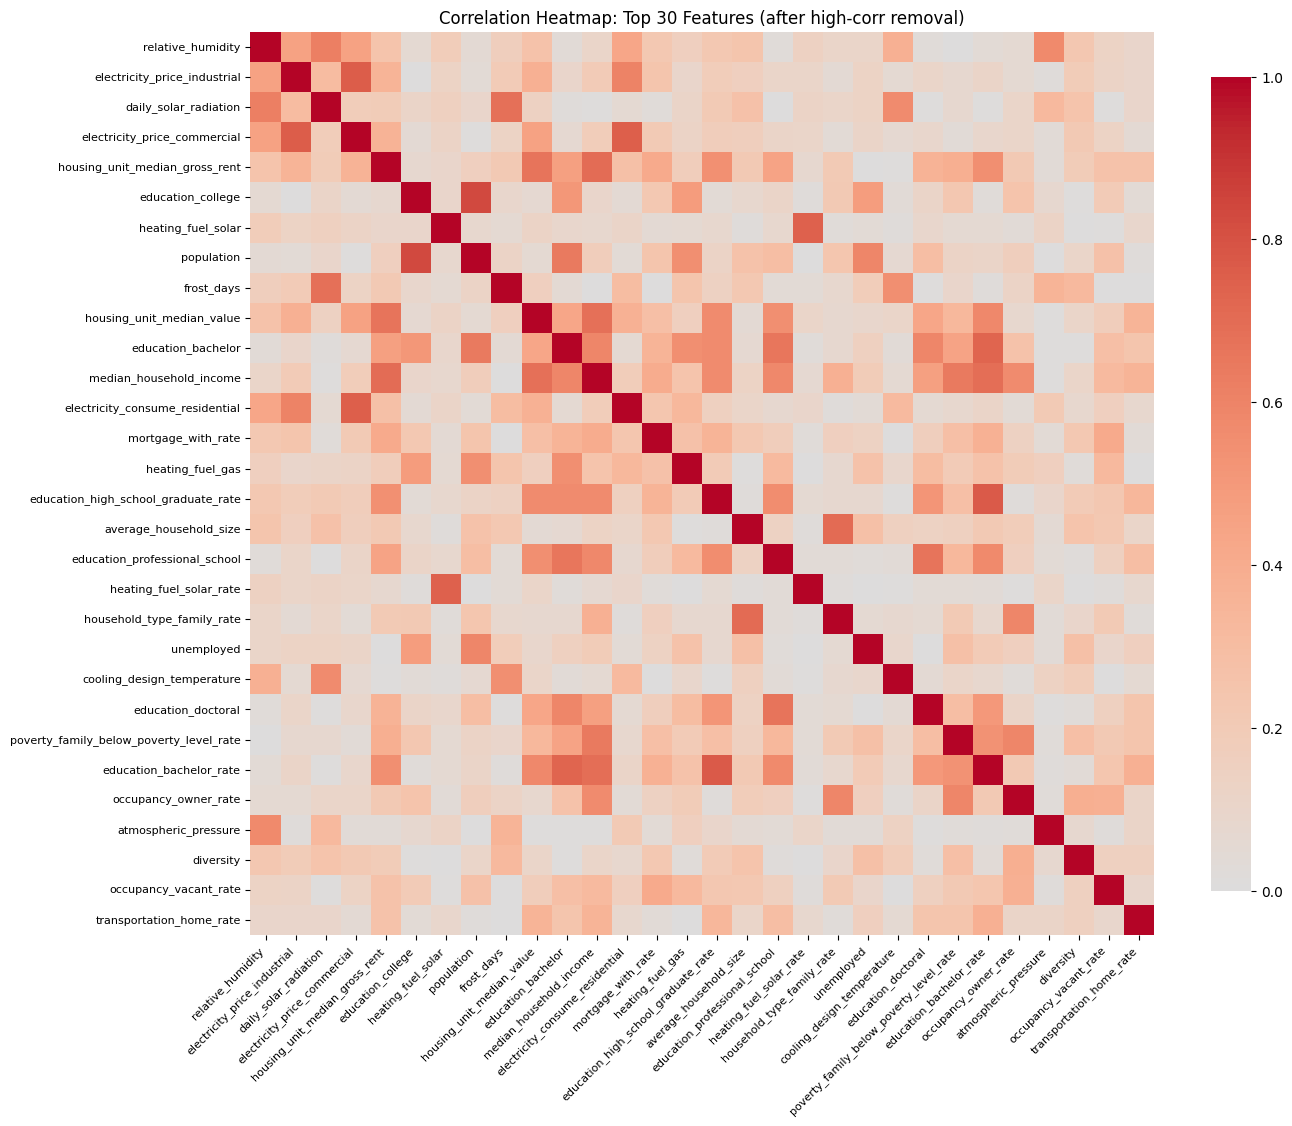

In [6]:
# Visualize correlation heatmap for remaining features (top 30 by target corr)
target_corr = df_clean[corr_selected + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
top30 = target_corr.head(31).index.tolist()  # includes target
top30.remove(target_col)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df_clean[top30].corr().abs(), cmap='coolwarm', center=0,
            square=True, ax=ax, xticklabels=True, yticklabels=True,
            vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap: Top 30 Features (after high-corr removal)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 2: VIF Screening

In [7]:
# Iterative VIF removal
remaining = corr_selected.copy()
vif_threshold = 10
max_iter = 50

for i in range(max_iter):
    vif_df = compute_vif(df_clean, remaining)
    max_vif = vif_df['VIF'].max()
    if max_vif <= vif_threshold:
        break
    drop_col = vif_df.iloc[0]['feature']
    remaining.remove(drop_col)
    print(f'Iter {i+1}: dropped {drop_col} (VIF={max_vif:.1f}), remaining={len(remaining)}')
else:
    print('Reached max iterations')

print(f'\nFinal feature count: {len(remaining)}')

Iter 1: dropped atmospheric_pressure (VIF=4316.6), remaining=93
Iter 2: dropped transportation_car_alone_rate (VIF=2125.7), remaining=92
Iter 3: dropped heating_fuel_gas_rate (VIF=1972.3), remaining=91
Iter 4: dropped employ_rate (VIF=1161.6), remaining=90
Iter 5: dropped cooling_design_temperature (VIF=869.9), remaining=89
Iter 6: dropped age_median (VIF=466.1), remaining=88
Iter 7: dropped travel_time_10_19_rate (VIF=372.0), remaining=87
Iter 8: dropped daily_solar_radiation (VIF=319.8), remaining=86
Iter 9: dropped population (VIF=250.6), remaining=85
Iter 10: dropped relative_humidity (VIF=230.3), remaining=84
Iter 11: dropped average_household_size (VIF=189.4), remaining=83
Iter 12: dropped dropout_16_19_inschool_rate (VIF=132.7), remaining=82
Iter 13: dropped education_college_rate (VIF=126.1), remaining=81
Iter 14: dropped household_type_family_rate (VIF=108.1), remaining=80
Iter 15: dropped education_high_school_graduate_rate (VIF=99.5), remaining=79
Iter 16: dropped travel_tim

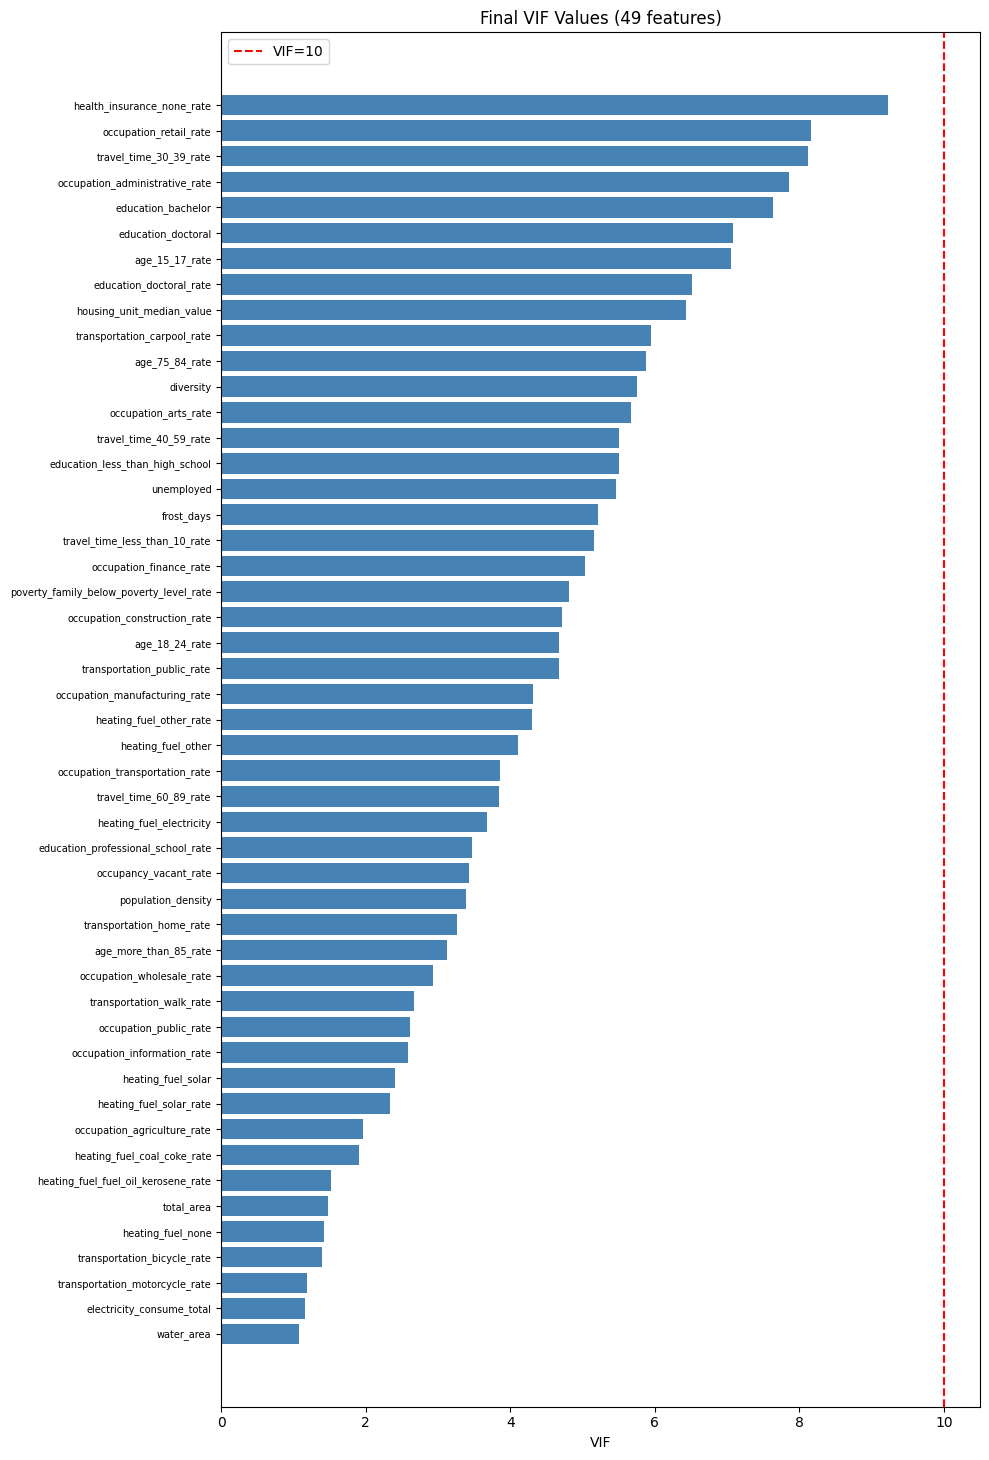

In [8]:
# Plot final VIF values
vif_final = compute_vif(df_clean, remaining)
fig, ax = plt.subplots(figsize=(10, max(6, len(vif_final)*0.3)))
colors = ['coral' if v > 10 else 'steelblue' for v in vif_final['VIF']]
ax.barh(range(len(vif_final)), vif_final['VIF'], color=colors)
ax.set_yticks(range(len(vif_final)))
ax.set_yticklabels(vif_final['feature'], fontsize=7)
ax.invert_yaxis()
ax.axvline(10, color='red', linestyle='--', label='VIF=10')
ax.set_xlabel('VIF')
ax.set_title(f'Final VIF Values ({len(vif_final)} features)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/02_vif_final.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Selected Features

In [9]:
selected_df = pd.DataFrame({'feature': remaining})
corr_series = df_clean[remaining].corrwith(df_clean[target_col])
selected_df['target_corr'] = selected_df['feature'].map(corr_series)
selected_df = selected_df.sort_values('target_corr', key=abs, ascending=False)
selected_df.to_csv('../outputs/results/selected_features.csv', index=False)
print('Saved to outputs/results/selected_features.csv')
print(selected_df.head(20))

Saved to outputs/results/selected_features.csv
                                    feature  target_corr
6                        heating_fuel_solar     0.245186
20                               frost_days    -0.230387
19                housing_unit_median_value     0.221682
0                        education_bachelor     0.216367
16                  heating_fuel_solar_rate     0.152038
9                                unemployed     0.145929
1                        education_doctoral     0.137368
13  poverty_family_below_poverty_level_rate    -0.121342
48                                diversity     0.104333
36                    occupancy_vacant_rate    -0.102371
37                 transportation_home_rate     0.102319
29           occupation_administrative_rate     0.098264
47               health_insurance_none_rate    -0.092252
30            occupation_manufacturing_rate    -0.087287
40           transportation_motorcycle_rate     0.080755
15              heating_fuel_coal_coke_ra

## Export Clean Dataset for Modeling

In [10]:
modeling_df = df_clean[remaining + ['potential_label']].copy()
modeling_df.to_csv('../data/processed/us_modeling_ready.csv', index=False)
print(f'Saved modeling dataset: {modeling_df.shape}')

Saved modeling dataset: (72537, 50)
